# AIAAIC × AIID Cross-Reference Notebook

**Goal:** Compare the AIAAIC repository against the AI Incident Database (AIID)
to identify where they agree, where they diverge, and what that tells us about
the reliability of AI incident tracking.

**Why this matters for the story:**
- The AIAAIC 2024→2025 "decline" needs to be tested against AIID's volume trend
- Different sourcing models (manual curation vs community submission) may surface different types of incidents

**Data sources:**
1. `aiaaic_cleaned.csv` — our cleaned AIAAIC data (from `clean.py`)
2. AIID yearly counts — via Our World in Data (Stanford AI Index sourced)
3. AIID GraphQL API — for richer incident-level data

---

## Setup

In [5]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import requests

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#cccccc",
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.5,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "figure.dpi":        130,
})

PAL = {
    "blue":   "#2E6DB4",  "purple": "#6B5DAD",  "teal":  "#1A8A6A",
    "coral":  "#C9522F",  "amber":  "#A66B17",  "pink":  "#B84A6B",
    "gray":   "#71706B",  "red":    "#C03E3E",  "green": "#4F8722",
}

print("✅ Setup complete")

✅ Setup complete


## Load AIAAIC cleaned data

In [2]:
aiaaic = pd.read_csv("AIAAIC/aiaaic_cleaned.csv")
bool_cols = [c for c in aiaaic.columns if c.startswith("is_") or c.startswith("has_")]
for c in bool_cols:
    aiaaic[c] = aiaaic[c].astype(bool)

aiaaic_yearly = aiaaic.groupby("year").size().rename("aiaaic_count")
print(f"AIAAIC: {len(aiaaic)} incidents, {int(aiaaic['year'].min())}–{int(aiaaic['year'].max())}")
aiaaic_yearly

AIAAIC: 2243 incidents, 2008–2026


year
2008.0      1
2009.0      5
2010.0      2
2011.0      2
2012.0     13
2013.0      6
2014.0     11
2015.0     20
2016.0     44
2017.0     66
2018.0     79
2019.0    122
2020.0    216
2021.0    248
2022.0    156
2023.0    373
2024.0    404
2025.0    262
2026.0     43
Name: aiaaic_count, dtype: int64

## Load AIID data (via Our World in Data / Stanford AI Index)

Our World in Data publishes the AIID yearly counts, sourced from the
Stanford AI Index Report. This gives us a clean year-over-year comparison.

In [6]:
# ── Fetch from Our World in Data ───────────────────────────
OWID_URL = (
    "https://ourworldindata.org/grapher/"
    "annual-reported-ai-incidents-controversies"
    ".csv?v=1&csvType=full&useColumnShortNames=false"
)

try:
    aiid_owid = pd.read_csv(OWID_URL, storage_options={"User-Agent": "AIAAIC-analysis/1.0"})
    aiid_owid = aiid_owid.rename(columns={
        "Year": "year",
        "Annual reported artificial intelligence incidents and controversies": "aiid_count"
    })[["year", "aiid_count"]]
    print(f"✅ Fetched AIID data from Our World in Data: {len(aiid_owid)} rows")
except Exception as e:
    print(f"⚠️  Could not fetch from OWID ({e}). Using embedded fallback data.")
    # Fallback: embedded from OWID as of May 2026
    aiid_owid = pd.DataFrame({
        "year":       [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
        "aiid_count": [   8,    6,   13,   24,   41,   50,   45,   43,   90,   77,  104,  168,  281,  362],
    })

aiid_owid

⚠️  Could not fetch from OWID (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>). Using embedded fallback data.


,year,aiid_count
0,2012,8
1,2013,6
2,2014,13
3,2015,24
4,2016,41
5,2017,50
6,2018,45
7,2019,43
8,2020,90
9,2021,77


## Fetch richer AIID data via GraphQL

The AIID GraphQL endpoint lets us pull individual incident records.
This cell fetches incident IDs, titles, and dates in paginated batches.

In [7]:
AIID_GRAPHQL = "https://incidentdatabase.ai/api/graphql"

def fetch_aiid_incidents(limit=2000):
    """Fetch incidents from AIID GraphQL API in paginated batches."""
    query = '''
    query ($skip: Int, $limit: Int) {
      incidents(limit: $limit, skip: $skip) {
        incident_id
        title
        date
        editor_dissimilar_incidents
        reports {
          report_number
          date_published
          title
        }
      }
    }
    '''
    all_incidents = []
    skip = 0
    batch_size = 200

    while skip < limit:
        try:
            resp = requests.post(
                AIID_GRAPHQL,
                json={"query": query, "variables": {"skip": skip, "limit": batch_size}},
                timeout=30,
            )
            if resp.status_code != 200:
                print(f"  ⚠️  API returned {resp.status_code} at skip={skip}, stopping.")
                break
            data = resp.json()
            batch = data.get("data", {}).get("incidents", [])
            if not batch:
                break
            all_incidents.extend(batch)
            skip += batch_size
            print(f"  Fetched {len(all_incidents)} incidents...", end="\r")
        except Exception as e:
            print(f"  ⚠️  API error at skip={skip}: {e}")
            break

    print(f"  Total AIID incidents fetched: {len(all_incidents)}")
    return all_incidents

try:
    aiid_raw = fetch_aiid_incidents(limit=2000)
    aiid_df = pd.DataFrame([{
        "incident_id": i["incident_id"],
        "title": i["title"],
        "date": i.get("date"),
        "n_reports": len(i.get("reports", [])),
    } for i in aiid_raw])
    aiid_df["year"] = pd.to_datetime(aiid_df["date"], errors="coerce").dt.year
    aiid_graphql_available = True
    print(f"\n✅ AIID GraphQL data: {len(aiid_df)} incidents")
except Exception as e:
    print(f"⚠️  GraphQL fetch failed: {e}")
    print("Continuing with OWID summary data only.")
    aiid_graphql_available = False

  ⚠️  API returned 403 at skip=0, stopping.
  Total AIID incidents fetched: 0
⚠️  GraphQL fetch failed: 'date'
Continuing with OWID summary data only.


## Volume comparison: AIAAIC vs AIID

The central question: does the AIAAIC 2024→2025 decline show up in AIID too?

In [8]:
# ── Merge yearly counts ────────────────────────────────────
compare = pd.DataFrame({"year": range(2012, 2027)})
compare = compare.merge(aiaaic_yearly.reset_index().rename(columns={"year": "year", 0: "aiaaic_count"}),
                        on="year", how="left")
# Handle both possible column name formats
if "aiaaic_count" not in compare.columns:
    rename_col = [c for c in compare.columns if c not in ["year"]][0]
    compare = compare.rename(columns={rename_col: "aiaaic_count"})
compare = compare.merge(aiid_owid, on="year", how="left")
compare = compare.fillna(0).astype({"aiaaic_count": int, "aiid_count": int})

print(compare.to_string(index=False))

 year  aiaaic_count  aiid_count
 2012            13           8
 2013             6           6
 2014            11          13
 2015            20          24
 2016            44          41
 2017            66          50
 2018            79          45
 2019           122          43
 2020           216          90
 2021           248          77
 2022           156         104
 2023           373         168
 2024           404         281
 2025           262         362
 2026            43           0


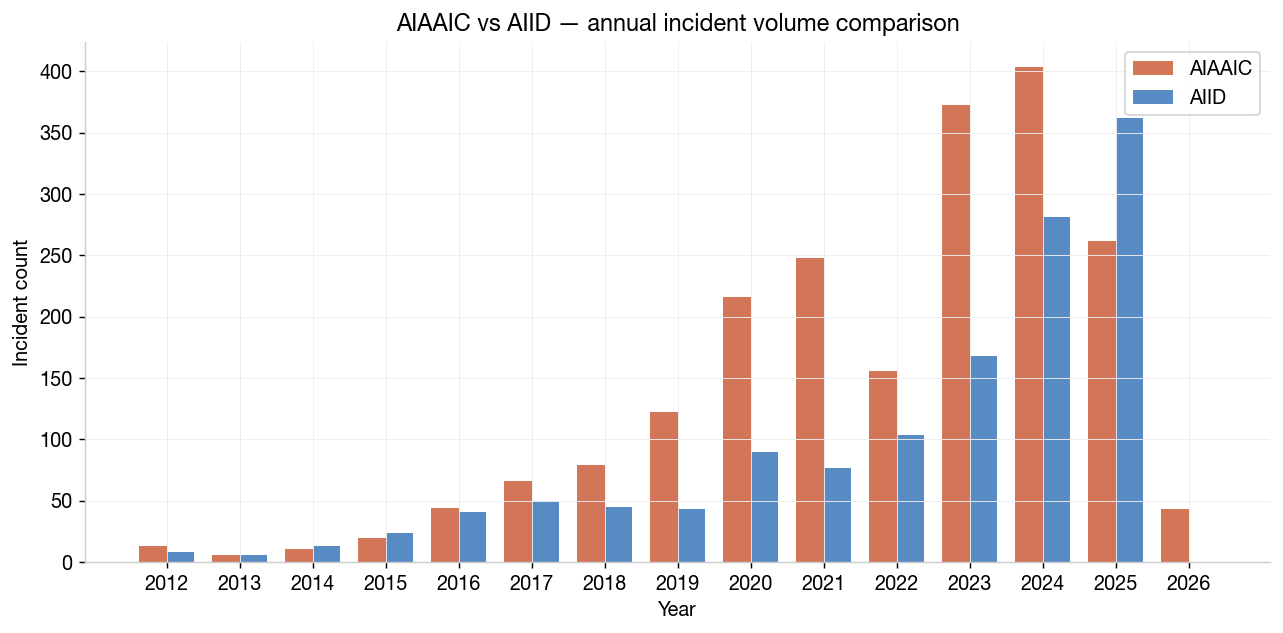

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(compare))
w = 0.38
ax.bar(x - w/2, compare["aiaaic_count"], w, color=PAL["coral"], alpha=0.8, label="AIAAIC")
ax.bar(x + w/2, compare["aiid_count"], w, color=PAL["blue"], alpha=0.8, label="AIID")

ax.set_xticks(x)
ax.set_xticklabels(compare["year"].astype(int), rotation=0)
ax.set(xlabel="Year", ylabel="Incident count",
       title="AIAAIC vs AIID — annual incident volume comparison")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Notes**
- AIAAIC consistently reports *more* incidents than AIID in every year. This likely reflects AIAAIC's broader inclusion criteria (they include "controversies" and near-misses alongside confirmed harm events).

## Year-over-year growth rates

Raw counts are misleading because the databases have different scales.
Growth rates normalise for that.

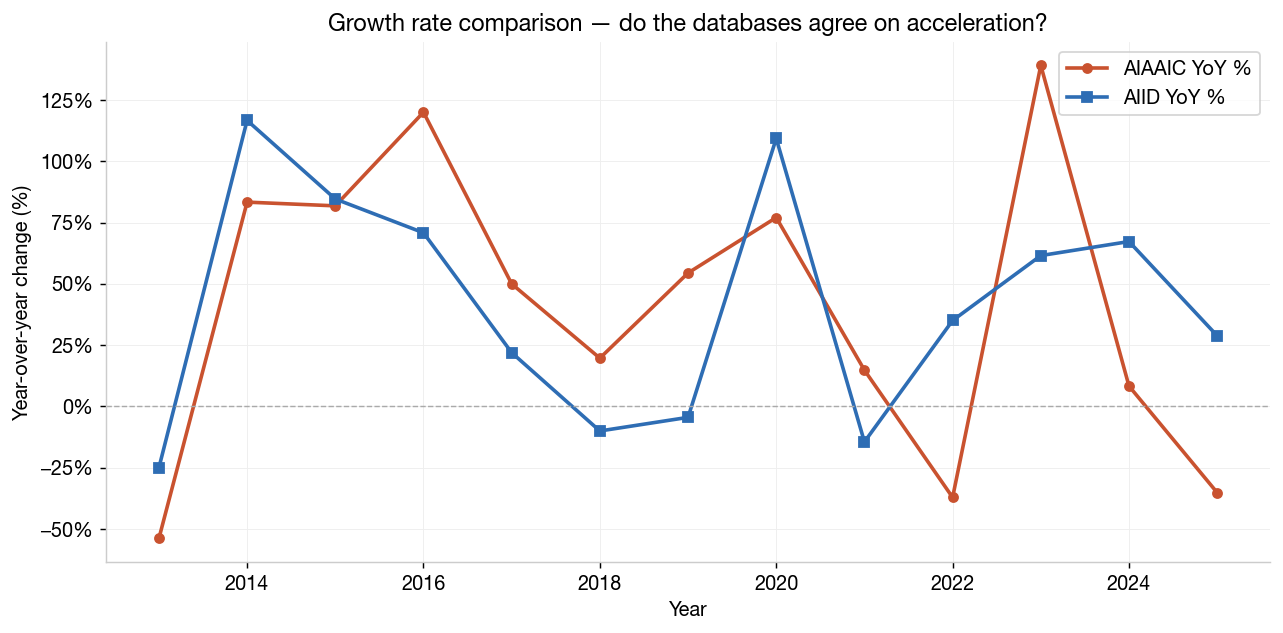

In [10]:
compare["aiaaic_yoy"] = compare["aiaaic_count"].pct_change() * 100
compare["aiid_yoy"] = compare["aiid_count"].pct_change() * 100

# Only plot years where both have data
plot_df = compare[(compare["aiaaic_count"] > 0) & (compare["aiid_count"] > 0)].copy()
plot_df = plot_df[plot_df["year"] >= 2013]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_df["year"], plot_df["aiaaic_yoy"], color=PAL["coral"], lw=2,
        marker="o", ms=5, label="AIAAIC YoY %")
ax.plot(plot_df["year"], plot_df["aiid_yoy"], color=PAL["blue"], lw=2,
        marker="s", ms=5, label="AIID YoY %")
ax.axhline(0, color="#aaa", lw=0.8, ls="--")

ax.set(xlabel="Year", ylabel="Year-over-year change (%)",
       title="Growth rate comparison — do the databases agree on acceleration?")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Notes** 
- Years where both lines move in the same direction = corroborated trend. 
- Years where they diverge = one database is catching something the other isn't or a curation bottleneck.

## AIAAIC-to-AIID ratio over time

How many more incidents does AIAAIC capture?

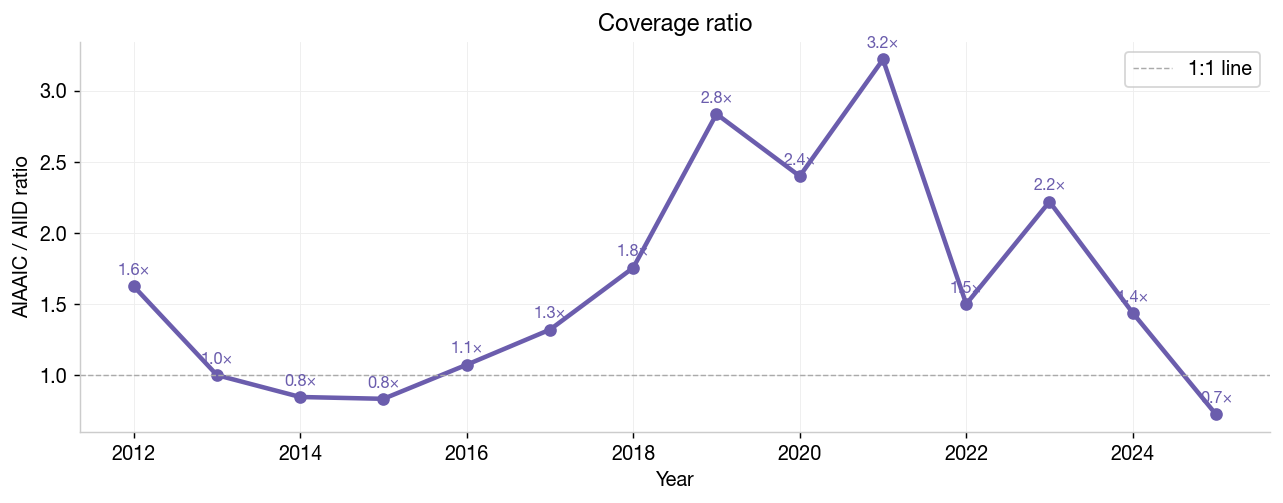

In [15]:
ratio = compare[compare["aiid_count"] > 0].copy()
ratio["ratio"] = ratio["aiaaic_count"] / ratio["aiid_count"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ratio["year"], ratio["ratio"], color=PAL["purple"], lw=2.5,
        marker="o", ms=6)
ax.axhline(1.0, color="#aaa", lw=0.8, ls="--", label="1:1 line")

for _, row in ratio.iterrows():
    ax.text(row["year"], row["ratio"] + 0.08, f'{row["ratio"]:.1f}×',
            ha="center", fontsize=9, color=PAL["purple"])

ax.set(xlabel="Year", ylabel="AIAAIC / AIID ratio",
       title="Coverage ratio")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Notes** 
- A rising ratio means AIAAIC is capturing proportionally more incidents than AIID.
- A falling ratio means AIAAIC is falling behind or AIID is catching up.
- The ratio drops sharply from 2024-2025, I think there is a lag

## Cumulative growth

total incidents over time

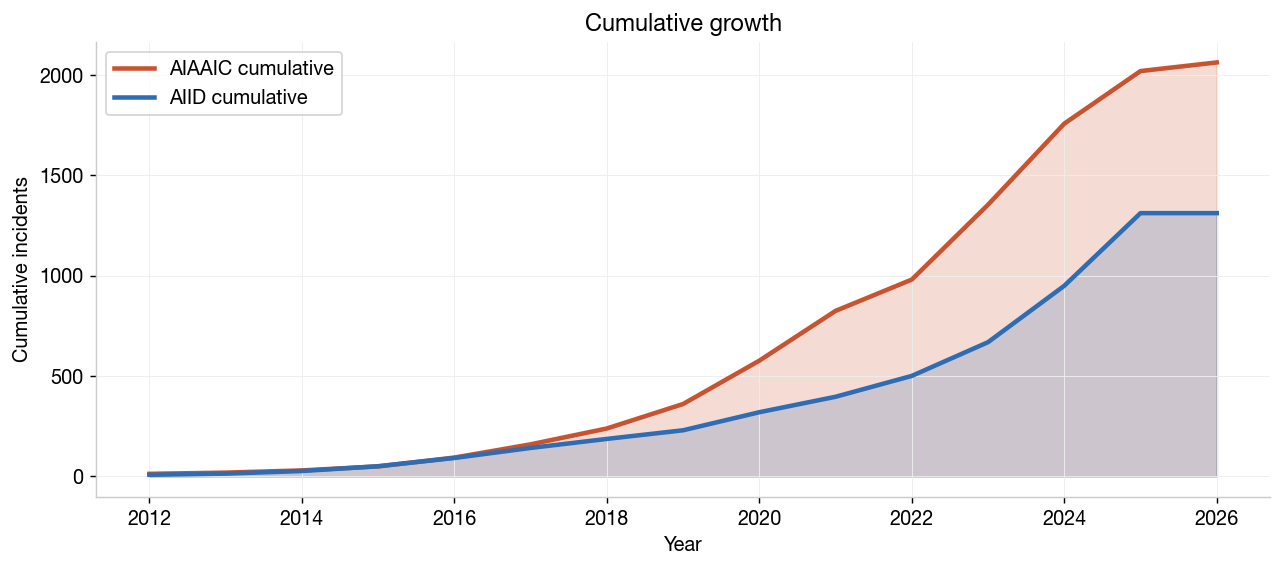

In [16]:
compare["aiaaic_cum"] = compare["aiaaic_count"].cumsum()
compare["aiid_cum"] = compare["aiid_count"].cumsum()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(compare["year"], compare["aiaaic_cum"], alpha=0.2, color=PAL["coral"])
ax.plot(compare["year"], compare["aiaaic_cum"], color=PAL["coral"], lw=2.5, label="AIAAIC cumulative")
ax.fill_between(compare["year"], compare["aiid_cum"], alpha=0.2, color=PAL["blue"])
ax.plot(compare["year"], compare["aiid_cum"], color=PAL["blue"], lw=2.5, label="AIID cumulative")

ax.set(xlabel="Year", ylabel="Cumulative incidents",
       title="Cumulative growth")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## AIID incident-level analysis 

In [ ]:
if aiid_graphql_available and len(aiid_df) > 0:
    # ── Reports per incident ──────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # a) AIID yearly from GraphQL
    aiid_yr_gql = aiid_df.groupby("year").size()
    ax1.bar(aiid_yr_gql.index, aiid_yr_gql.values, color=PAL["blue"], alpha=0.7)
    ax1.set(xlabel="Year", ylabel="Incidents",
            title="AIID incidents by year (GraphQL)")
    ax1.spines[["top", "right"]].set_visible(False)

    # b) Reports per incident distribution
    rpd = aiid_df["n_reports"].clip(upper=20)
    ax2.hist(rpd, bins=range(0, 22), color=PAL["teal"], alpha=0.7, edgecolor="white")
    ax2.set(xlabel="Reports per incident", ylabel="Count",
            title="AIID reporting density")
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────
    print(f"AIID incidents (GraphQL): {len(aiid_df)}")
    print(f"Median reports per incident: {aiid_df['n_reports'].median():.0f}")
    print(f"Mean reports per incident: {aiid_df['n_reports'].mean():.1f}")
    print(f"Max reports: {aiid_df['n_reports'].max()}")
else:   
    print("GraphQL data not available. Skipping incident-level analysis.")
    print("To get richer AIID data, download a snapshot from:")
    print("https://incidentdatabase.ai/research/snapshots/")

GraphQL data not available. Skipping incident-level analysis.
To get richer AIID data, download a snapshot from:
https://incidentdatabase.ai/research/snapshots/


## Structural comparison: AIAAIC vs AIID

In [18]:
comparison_table = pd.DataFrame({
    "Dimension": [
        "Maintained by",
        "Sourcing model",
        "Scope",
        "Total incidents",
        "Year range",
        "Taxonomy",
        "Harm coding",
        "Consequence tracking",
        "Update frequency",
        "Access method",
        "Key strength",
        "Key limitation",
    ],
    "AIAAIC": [
        "Charlie Pownall (solo curator)",
        "Manual curation from media/research",
        "Incidents + controversies + near-misses",
        "~2,243 (as of May 2026)",
        "2008–2026",
        "Custom: 241 tech types, 120 ethics types",
        "Individual + Societal + Environmental (semicolon-coded)",
        "Yes — consequence + response fields",
        "Continuous (manual)",
        "Google Sheets / CSV export",
        "Breadth — includes controversies, not just confirmed harm",
        "Single curator bottleneck; English-language bias; taxonomy fragmentation",
    ],
    "AIID": [
        "Responsible AI Collaborative (team)",
        "Community submissions + editorial review",
        "Confirmed AI harm or near-harm events",
        "~1,400+ (as of early 2026)",
        "2012–2026",
        "MIT AI Risk Repository taxonomy (applied by LLM classifier)",
        "MIT CSET severity taxonomy (LLM-classified)",
        "Not directly — links to news reports",
        "Continuous (community + editorial)",
        "GraphQL API / MongoDB snapshots",
        "Structured severity ratings; scalable classification",
        "LLM classification not fully validated; community submission bias",
    ],
})

# Display as formatted table
from IPython.display import display, HTML
display(HTML(comparison_table.to_html(index=False, classes="table")))

Dimension,AIAAIC,AIID
Maintained by,Charlie Pownall (solo curator),Responsible AI Collaborative (team)
Sourcing model,Manual curation from media/research,Community submissions + editorial review
Scope,Incidents + controversies + near-misses,Confirmed AI harm or near-harm events
Total incidents,"~2,243 (as of May 2026)","~1,400+ (as of early 2026)"
Year range,2008–2026,2012–2026
Taxonomy,"Custom: 241 tech types, 120 ethics types",MIT AI Risk Repository taxonomy (applied by LLM classifier)
Harm coding,Individual + Societal + Environmental (semicolon-coded),MIT CSET severity taxonomy (LLM-classified)
Consequence tracking,Yes — consequence + response fields,Not directly — links to news reports
Update frequency,Continuous (manual),Continuous (community + editorial)
Access method,Google Sheets / CSV export,GraphQL API / MongoDB snapshots


**Notes** 
- These databases use fundamentally different methods: manual curation vs community submission, custom taxonomy vs LLM-applied taxonomy.

## General Thoughts

- AI incidents are accelerating. Both databases show year-over-year growth
- GenAI is the dominant driver since 2023. AIID's MIT taxonomy also shows misinformation/malicious actors as the fastest-growing domain
- Both databases have strong English-language bias
- Accountability rates. AIAAIC tracks consequences, we can't cross-validate this with AIID